## Análise Exploratória — Job Skill Set Dataset

O dataset **Job Skill Set** foi analisado com o objetivo de entender sua estrutura e avaliar como ele poderá ser utilizado dentro do projeto JobMatch AI. Essa base tem como principal finalidade fornecer informações sobre cargos, descrições de vagas e conjuntos de habilidades exigidas, sendo especialmente útil para tarefas de extração de skills, recomendação de vagas e comparação entre perfil do candidato e requisitos da oportunidade.

A base possui **1.167 registros** e **5 colunas originais**: `job_id`, `category`, `job_title`, `job_description` e `job_skill_set`. A coluna `job_id` representa o identificador único da vaga, `category` indica a área ou setor da vaga, `job_title` representa o cargo, `job_description` contém a descrição textual da vaga e `job_skill_set` armazena a lista de habilidades associadas à posição.

Durante a análise de qualidade dos dados, não foram encontrados valores ausentes nas colunas principais. Também foi verificado que todos os `job_id` são únicos, não havendo registros duplicados. Isso indica que a base está bem estruturada e pode ser utilizada com segurança nas próximas etapas do projeto.

A distribuição das vagas por categoria mostrou um equilíbrio razoável entre as cinco áreas presentes no dataset. A categoria **Information Technology** possui 240 registros, seguida por **Business Development** com 239, **Finance** com 236, **Sales** com 232 e **HR** com 220. Essa distribuição equilibrada é positiva, pois permite analisar diferentes áreas profissionais sem que uma categoria domine excessivamente a base.

Em relação aos cargos, foram identificados **723 títulos únicos**, o que demonstra uma boa diversidade de funções. Entre os cargos mais frequentes estão **Business Development Manager**, **Human Resources Generalist**, **Business Development Representative**, **Human Resources Manager**, **Information Technology Support Specialist** e **Finance Manager**. Isso mostra que a base cobre diferentes perfis profissionais, especialmente nas áreas de negócios, tecnologia, finanças, vendas e recursos humanos.

As descrições das vagas apresentaram tamanho médio de aproximadamente **3.768 caracteres** e **516 palavras**. Esse resultado indica que os textos possuem conteúdo suficiente para aplicação de técnicas de Processamento de Linguagem Natural, como TF-IDF, extração de termos e comparação textual entre currículos e descrições de vagas.

A coluna `job_skill_set` foi convertida de texto para lista, permitindo analisar a quantidade de habilidades associadas a cada vaga. Em média, cada vaga possui **17,85 skills**. A mediana foi de 18 skills, com mínimo de 5 e máximo de 43 habilidades por vaga. Esses valores mostram que o dataset oferece uma quantidade relevante de informações sobre requisitos profissionais, tornando-o adequado para a etapa de análise de skills do projeto.

Após a normalização e expansão das listas de habilidades, foi criada uma tabela com **20.833 ocorrências de skills**, em que cada linha representa uma habilidade associada a uma vaga. As habilidades mais frequentes foram **communication**, **problem solving**, **adaptability**, **teamwork**, **collaboration**, **leadership**, **time management**, **interpersonal skills**, **customer service** e **relationship building**.

Um ponto importante observado é que as skills mais frequentes não são apenas técnicas, mas também comportamentais. Isso indica que o dataset contempla tanto hard skills quanto soft skills, o que pode enriquecer a análise de compatibilidade entre candidato e vaga. No contexto do JobMatch AI, isso permite que o sistema não apenas calcule um score de aderência, mas também explique quais habilidades do candidato estão alinhadas com a vaga e quais ainda precisam ser desenvolvidas.

Dessa forma, o Job Skill Set Dataset será utilizado principalmente para enriquecer a análise de vagas com habilidades exigidas. Ele será útil para comparar as skills presentes no currículo do usuário com as skills associadas às vagas, identificar habilidades compatíveis, apontar skills faltantes e gerar sugestões de desenvolvimento profissional.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import ast
import kagglehub

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

In [2]:
path = kagglehub.dataset_download("batuhanmutlu/job-skill-set")

DATASET_PATH = Path(path)

print("Path to dataset files:", DATASET_PATH)
print("A pasta existe?", DATASET_PATH.exists())

Using Colab cache for faster access to the 'job-skill-set' dataset.
Path to dataset files: /kaggle/input/job-skill-set
A pasta existe? True


In [3]:
arquivos = sorted(DATASET_PATH.rglob("*"))

for arquivo in arquivos:
    if arquivo.is_file():
        print(arquivo.relative_to(DATASET_PATH))

all_job_post.csv


In [4]:
caminho_csv = DATASET_PATH / "all_job_post.csv"

if not caminho_csv.exists():
    raise FileNotFoundError("Arquivo all_job_post.csv não encontrado.")

df_skills = pd.read_csv(caminho_csv)

print("Dataset carregado com sucesso.")
print("Formato:", df_skills.shape)

df_skills.head()

Dataset carregado com sucesso.
Formato: (1167, 5)


,job_id,category,job_title,job_description,job_skill_set
0,3902668440,HR,Sr Human Resource Generalist,"SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXPERTISE ACROSS VARIOUS FUNCTIONS INCLUDING EMPLOYEE RELATIONS, TALENT A...","['employee relations', 'talent acquisition', 'performance management', 'compensation and benefits', 'employment laws..."
1,3905823748,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGER OF HUMAN RESOURCES. JOIN US AS YSB ENTERS A NEW AND VIBRANT ERA WITH...,"['Talent Acquisition', 'Employee Performance Management', 'Legal Compliance', 'Payroll Processing', 'Microsoft Offic..."
2,3905854799,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING A UNIQUE OPPORTUNITY FOR A DIRECTOR OF HUMAN RESOURCES TO JOIN ITS DY...,"['Human Resources Management', 'Recruitment', 'Employee Relations', 'Performance Management', 'Compliance with Labor..."
3,3905834061,HR,Chief Human Resources Officer,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO)INDUSTRY: ENTERTAINMENT & MEDIA \nJOB DESCRIPTION:EAST 57TH STREET PA...,"['talent management', 'organizational development', 'HR compliance', 'HR technology systems', 'data-driven HR analyt..."
4,3906250451,HR,Human Resources Generalist (Hybrid Role),DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DIGITAL ENABLEMENT SOLUTIONS PROVIDER WHO TRANSFORMS HOW PEOPLE AND TECH...,"['Microsoft Office', 'Data analysis', 'Employee onboarding', 'Strategic thinking', 'Problem solving', 'Time manageme..."


In [5]:
print("1. Quantas linhas existem?")
print(df_skills.shape[0])

print("\n2. Quantas colunas existem?")
print(df_skills.shape[1])

print("\n3. Quais colunas existem?")
for coluna in df_skills.columns:
    print("-", coluna)

1. Quantas linhas existem?
1167

2. Quantas colunas existem?
5

3. Quais colunas existem?
- job_id
- category
- job_title
- job_description
- job_skill_set


In [6]:
resumo_colunas = pd.DataFrame({
    "coluna": df_skills.columns,
    "tipo": df_skills.dtypes.astype(str).values,
    "qtd_nulos": df_skills.isna().sum().values,
    "percentual_nulos": (df_skills.isna().mean().values * 100).round(2),
    "qtd_valores_unicos": df_skills.nunique(dropna=True).values
})

resumo_colunas

,coluna,tipo,qtd_nulos,percentual_nulos,qtd_valores_unicos
0,job_id,int64,0,0.0,1167
1,category,object,0,0.0,5
2,job_title,object,0,0.0,723
3,job_description,object,0,0.0,1167
4,job_skill_set,object,0,0.0,1167


In [7]:
coluna_id = "job_id"
coluna_categoria = "category"
coluna_cargo = "job_title"
coluna_descricao = "job_description"
coluna_skills = "job_skill_set"

print("Coluna que representa o ID da vaga:", coluna_id)
print("Coluna que representa a categoria:", coluna_categoria)
print("Coluna que representa o cargo:", coluna_cargo)
print("Coluna que representa a descrição da vaga:", coluna_descricao)
print("Coluna que representa as skills:", coluna_skills)

Coluna que representa o ID da vaga: job_id
Coluna que representa a categoria: category
Coluna que representa o cargo: job_title
Coluna que representa a descrição da vaga: job_description
Coluna que representa as skills: job_skill_set


In [8]:
ids_vazios = df_skills["job_id"].isna().sum()
categorias_vazias = df_skills["category"].fillna("").astype(str).str.strip().eq("").sum()
cargos_vazios = df_skills["job_title"].fillna("").astype(str).str.strip().eq("").sum()
descricoes_vazias = df_skills["job_description"].fillna("").astype(str).str.strip().eq("").sum()
skills_vazias = df_skills["job_skill_set"].fillna("").astype(str).str.strip().eq("").sum()

print("IDs vazios:", ids_vazios)
print("Categorias vazias:", categorias_vazias)
print("Cargos vazios:", cargos_vazios)
print("Descrições vazias:", descricoes_vazias)
print("Skills vazias:", skills_vazias)

IDs vazios: 0
Categorias vazias: 0
Cargos vazios: 0
Descrições vazias: 0
Skills vazias: 0


In [9]:
qtd_job_id_unicos = df_skills["job_id"].nunique()
qtd_job_id_duplicados = df_skills["job_id"].duplicated().sum()

print("Quantidade de job_id únicos:", qtd_job_id_unicos)
print("Quantidade de job_id duplicados:", qtd_job_id_duplicados)
print("Total de linhas:", len(df_skills))

Quantidade de job_id únicos: 1167
Quantidade de job_id duplicados: 0
Total de linhas: 1167


category
INFORMATION-TECHNOLOGY    240
BUSINESS-DEVELOPMENT      239
FINANCE                   236
SALES                     232
HR                        220
Name: count, dtype: int64


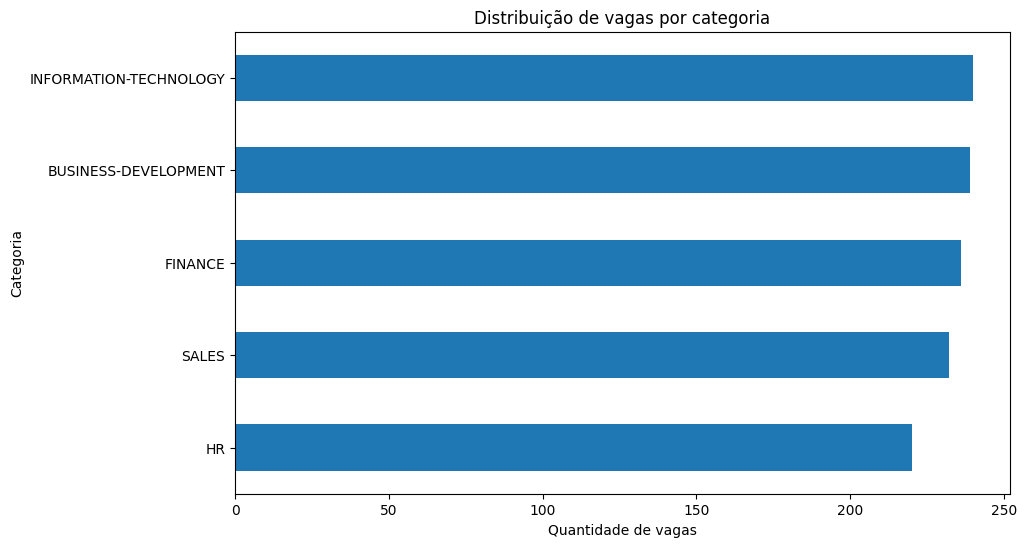

In [10]:
contagem_categorias = df_skills["category"].value_counts(dropna=False)

print(contagem_categorias)

plt.figure(figsize=(10, 6))
contagem_categorias.sort_values().plot(kind="barh")
plt.title("Distribuição de vagas por categoria")
plt.xlabel("Quantidade de vagas")
plt.ylabel("Categoria")
plt.show()

job_title
Business Development Manager                  53
Human Resources Generalist                    34
Business Development Representative           33
Human Resources Manager                       28
Information Technology Support Specialist     16
Finance Manager                               15
Human Resources Business Partner              15
Director of Finance                           13
Human Resources Coordinator                   11
Information Technology Project Manager        11
Information Technology Manager                10
Director of Information Technology            10
Information Technology Project Coordinator    10
Human Resources Specialist                     9
Salesperson                                    8
Sales Manager                                  8
Human Resources Director                       7
Information Technology Specialist              7
Human Resources Assistant                      7
Business Development Specialist                7
Name: coun

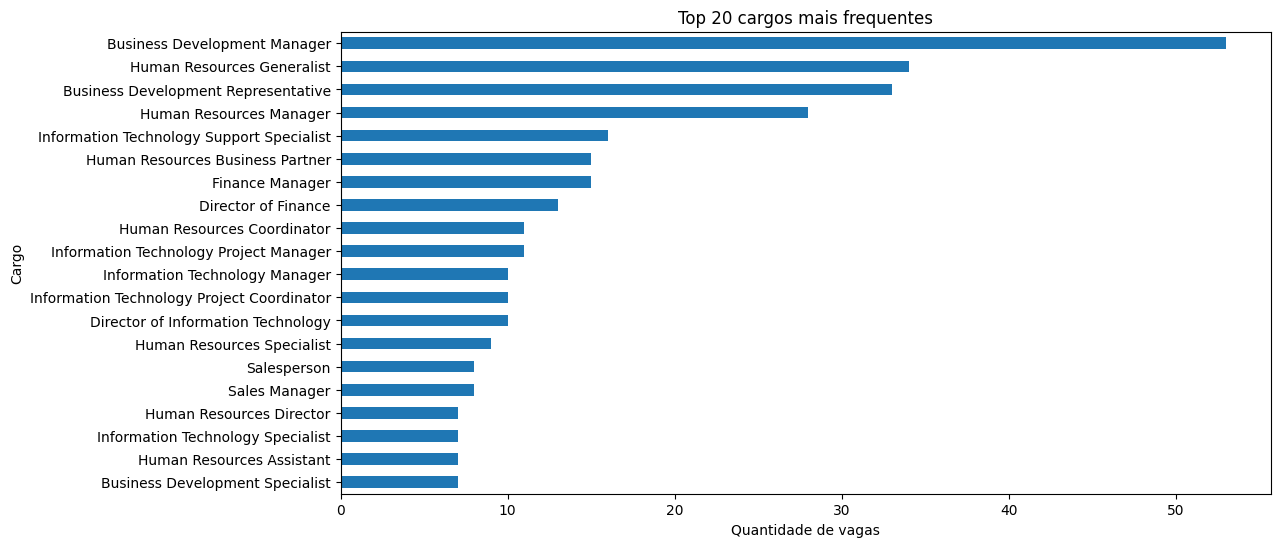

In [11]:
top_cargos = df_skills["job_title"].value_counts().head(20)

print(top_cargos)

plt.figure(figsize=(12, 6))
top_cargos.sort_values().plot(kind="barh")
plt.title("Top 20 cargos mais frequentes")
plt.xlabel("Quantidade de vagas")
plt.ylabel("Cargo")
plt.show()

In [12]:
df_skills["tamanho_descricao"] = df_skills["job_description"].fillna("").astype(str).str.len()
df_skills["qtd_palavras_descricao"] = df_skills["job_description"].fillna("").astype(str).str.split().str.len()

print("Tamanho médio da descrição em caracteres:")
print(round(df_skills["tamanho_descricao"].mean(), 2))

print("\nQuantidade média de palavras na descrição:")
print(round(df_skills["qtd_palavras_descricao"].mean(), 2))

df_skills[["job_title", "job_description", "tamanho_descricao", "qtd_palavras_descricao"]].head()

Tamanho médio da descrição em caracteres:
3768.32

Quantidade média de palavras na descrição:
516.82


,job_title,job_description,tamanho_descricao,qtd_palavras_descricao
0,Sr Human Resource Generalist,"SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXPERTISE ACROSS VARIOUS FUNCTIONS INCLUDING EMPLOYEE RELATIONS, TALENT A...",4397,583
1,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGER OF HUMAN RESOURCES. JOIN US AS YSB ENTERS A NEW AND VIBRANT ERA WITH...,2529,323
2,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING A UNIQUE OPPORTUNITY FOR A DIRECTOR OF HUMAN RESOURCES TO JOIN ITS DY...,4910,666
3,Chief Human Resources Officer,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO)INDUSTRY: ENTERTAINMENT & MEDIA \nJOB DESCRIPTION:EAST 57TH STREET PA...,3387,416
4,Human Resources Generalist (Hybrid Role),DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DIGITAL ENABLEMENT SOLUTIONS PROVIDER WHO TRANSFORMS HOW PEOPLE AND TECH...,4811,604


In [13]:
def converter_skills_para_lista(valor):
    if pd.isna(valor):
        return []

    if isinstance(valor, list):
        return valor

    texto = str(valor).strip()

    if texto == "":
        return []

    try:
        resultado = ast.literal_eval(texto)

        if isinstance(resultado, list):
            return resultado

        return []
    except Exception:
        return []


df_skills["skills_lista"] = df_skills["job_skill_set"].apply(converter_skills_para_lista)

df_skills[["job_title", "job_skill_set", "skills_lista"]].head()

,job_title,job_skill_set,skills_lista
0,Sr Human Resource Generalist,"['employee relations', 'talent acquisition', 'performance management', 'compensation and benefits', 'employment laws...","[employee relations, talent acquisition, performance management, compensation and benefits, employment laws and regu..."
1,Human Resources Manager,"['Talent Acquisition', 'Employee Performance Management', 'Legal Compliance', 'Payroll Processing', 'Microsoft Offic...","[Talent Acquisition, Employee Performance Management, Legal Compliance, Payroll Processing, Microsoft Office, Policy..."
2,Director of Human Resources,"['Human Resources Management', 'Recruitment', 'Employee Relations', 'Performance Management', 'Compliance with Labor...","[Human Resources Management, Recruitment, Employee Relations, Performance Management, Compliance with Labor Laws, Da..."
3,Chief Human Resources Officer,"['talent management', 'organizational development', 'HR compliance', 'HR technology systems', 'data-driven HR analyt...","[talent management, organizational development, HR compliance, HR technology systems, data-driven HR analytics, comp..."
4,Human Resources Generalist (Hybrid Role),"['Microsoft Office', 'Data analysis', 'Employee onboarding', 'Strategic thinking', 'Problem solving', 'Time manageme...","[Microsoft Office, Data analysis, Employee onboarding, Strategic thinking, Problem solving, Time management, Attenti..."


Quantidade média de skills por vaga:
17.85

Resumo estatístico da quantidade de skills:


,qtd_skills
count,1167.000000
mean,17.851757
std,4.980524
min,5.000000
25%,15.000000
50%,18.000000
75%,20.000000
max,43.000000


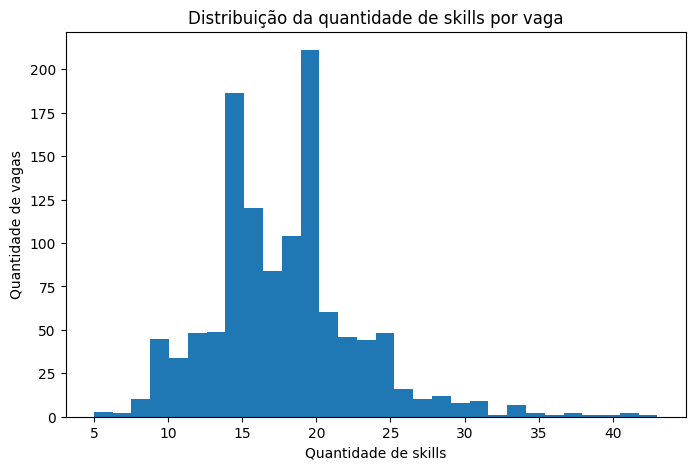

In [14]:
df_skills["qtd_skills"] = df_skills["skills_lista"].apply(len)

print("Quantidade média de skills por vaga:")
print(round(df_skills["qtd_skills"].mean(), 2))

print("\nResumo estatístico da quantidade de skills:")
display(df_skills["qtd_skills"].describe())

plt.figure(figsize=(8, 5))
df_skills["qtd_skills"].plot(kind="hist", bins=30)
plt.title("Distribuição da quantidade de skills por vaga")
plt.xlabel("Quantidade de skills")
plt.ylabel("Quantidade de vagas")
plt.show()

In [15]:
def normalizar_skill(skill):
    skill = str(skill).strip().lower()
    skill = " ".join(skill.split())
    return skill


df_skills["skills_normalizadas"] = df_skills["skills_lista"].apply(
    lambda lista: [normalizar_skill(skill) for skill in lista if str(skill).strip() != ""]
)

df_skills[["job_title", "skills_lista", "skills_normalizadas"]].head()

,job_title,skills_lista,skills_normalizadas
0,Sr Human Resource Generalist,"[employee relations, talent acquisition, performance management, compensation and benefits, employment laws and regu...","[employee relations, talent acquisition, performance management, compensation and benefits, employment laws and regu..."
1,Human Resources Manager,"[Talent Acquisition, Employee Performance Management, Legal Compliance, Payroll Processing, Microsoft Office, Policy...","[talent acquisition, employee performance management, legal compliance, payroll processing, microsoft office, policy..."
2,Director of Human Resources,"[Human Resources Management, Recruitment, Employee Relations, Performance Management, Compliance with Labor Laws, Da...","[human resources management, recruitment, employee relations, performance management, compliance with labor laws, da..."
3,Chief Human Resources Officer,"[talent management, organizational development, HR compliance, HR technology systems, data-driven HR analytics, comp...","[talent management, organizational development, hr compliance, hr technology systems, data-driven hr analytics, comp..."
4,Human Resources Generalist (Hybrid Role),"[Microsoft Office, Data analysis, Employee onboarding, Strategic thinking, Problem solving, Time management, Attenti...","[microsoft office, data analysis, employee onboarding, strategic thinking, problem solving, time management, attenti..."


In [16]:
df_skills_expandido = df_skills[[
    "job_id",
    "category",
    "job_title",
    "skills_normalizadas"
]].explode("skills_normalizadas")

df_skills_expandido = df_skills_expandido.rename(
    columns={"skills_normalizadas": "skill"}
)

df_skills_expandido = df_skills_expandido.dropna(subset=["skill"])
df_skills_expandido = df_skills_expandido[df_skills_expandido["skill"].str.strip() != ""]

print("Formato da tabela expandida:")
print(df_skills_expandido.shape)

df_skills_expandido.head()

Formato da tabela expandida:
(20833, 4)


,job_id,category,job_title,skill
0,3902668440,HR,Sr Human Resource Generalist,employee relations
0,3902668440,HR,Sr Human Resource Generalist,talent acquisition
0,3902668440,HR,Sr Human Resource Generalist,performance management
0,3902668440,HR,Sr Human Resource Generalist,compensation and benefits
0,3902668440,HR,Sr Human Resource Generalist,employment laws and regulations


skill
communication                       1092
problem solving                      878
adaptability                         588
teamwork                             569
collaboration                        341
leadership                           325
time management                      316
interpersonal skills                 288
customer service                     272
relationship building                267
attention to detail                  253
data analysis                        251
project management                   234
organizational skills                231
negotiation                          157
sales                                148
presentation skills                  144
business development                 137
financial analysis                   131
strategic thinking                   127
analytical skills                    122
team collaboration                   107
self-motivation                      105
employee relations                   103
financial 

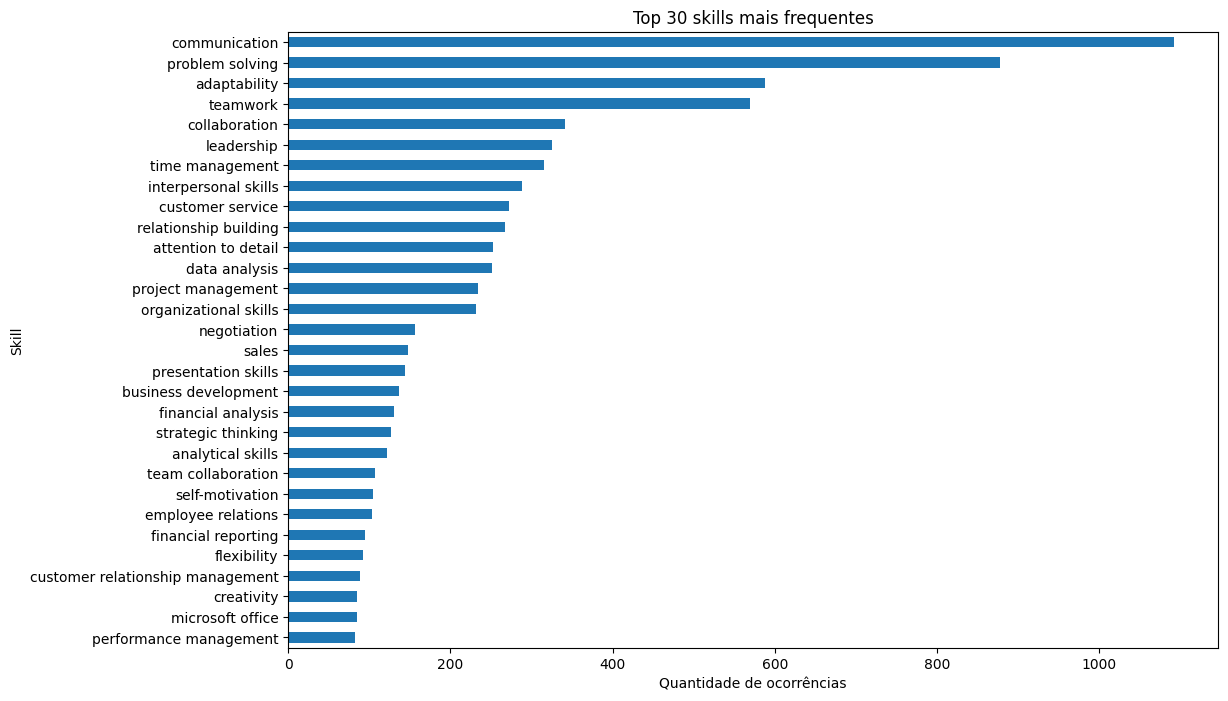

In [17]:
top_skills = df_skills_expandido["skill"].value_counts().head(30)

print(top_skills)

plt.figure(figsize=(12, 8))
top_skills.sort_values().plot(kind="barh")
plt.title("Top 30 skills mais frequentes")
plt.xlabel("Quantidade de ocorrências")
plt.ylabel("Skill")
plt.show()

In [18]:
categorias = df_skills["category"].dropna().unique()

for categoria in categorias:
    print("=" * 80)
    print("Categoria:", categoria)

    top_skills_categoria = (
        df_skills_expandido[df_skills_expandido["category"] == categoria]["skill"]
        .value_counts()
        .head(10)
    )

    print(top_skills_categoria)

Categoria: HR
skill
communication             207
problem solving           171
employee relations        102
adaptability              102
teamwork                  101
interpersonal skills       99
attention to detail        81
performance management     79
data analysis              76
leadership                 72
Name: count, dtype: int64
Categoria: INFORMATION-TECHNOLOGY
skill
communication          219
problem solving        191
adaptability           112
teamwork               101
collaboration           88
project management      84
leadership              69
customer service        66
time management         57
attention to detail     51
Name: count, dtype: int64
Categoria: SALES
skill
communication                       220
problem solving                     162
teamwork                            147
adaptability                        135
customer service                    120
sales                                77
time management                      73
relationship bu

In [19]:
for categoria in categorias:
    print("=" * 80)
    print("Categoria:", categoria)

    top_cargos_categoria = (
        df_skills[df_skills["category"] == categoria]["job_title"]
        .value_counts()
        .head(10)
    )

    print(top_cargos_categoria)

Categoria: HR
job_title
Human Resources Generalist                 34
Human Resources Manager                    28
Human Resources Business Partner           15
Human Resources Coordinator                11
Human Resources Specialist                  9
Human Resources Assistant                   7
Human Resources Director                    7
Director of Human Resources                 5
Senior Human Resources Business Partner     5
Vice President Human Resources              4
Name: count, dtype: int64
Categoria: INFORMATION-TECHNOLOGY
job_title
Information Technology Support Specialist        16
Information Technology Project Manager           11
Director of Information Technology               10
Information Technology Manager                   10
Information Technology Project Coordinator       10
Information Technology Specialist                 7
Information Technology Technician                 6
Information Technology System Administrator       6
Information Technology Support

In [20]:
def juntar_texto_vaga(linha):
    partes = []

    for coluna in ["job_title", "job_description", "job_skill_set"]:
        if coluna in linha.index and pd.notna(linha[coluna]):
            texto = str(linha[coluna]).strip()

            if texto != "":
                partes.append(texto)

    return " ".join(partes)


df_skills["texto_vaga_completo"] = df_skills.apply(juntar_texto_vaga, axis=1)

df_skills[["job_title", "texto_vaga_completo"]].head()

,job_title,texto_vaga_completo
0,Sr Human Resource Generalist,Sr Human Resource Generalist SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXPERTISE ACROSS VARIOUS FUNCTIONS INCLUDING...
1,Human Resources Manager,Human Resources Manager BE PART OF A STELLAR TEAM AT YSB AS THE MANAGER OF HUMAN RESOURCES. JOIN US AS YSB ENTERS A ...
2,Director of Human Resources,Director of Human Resources OUR CLIENT IS A THRIVING ORGANIZATION OFFERING A UNIQUE OPPORTUNITY FOR A DIRECTOR OF HU...
3,Chief Human Resources Officer,Chief Human Resources Officer JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO)INDUSTRY: ENTERTAINMENT & MEDIA \nJOB D...
4,Human Resources Generalist (Hybrid Role),Human Resources Generalist (Hybrid Role) DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DIGITAL ENABLEMENT SOLUTIONS PR...


In [21]:
print("Resumo final da EDA — Job Skill Set")
print("=" * 70)

print("\n1. Quantidade de linhas:")
print(df_skills.shape[0])

print("\n2. Quantidade de colunas originais:")
print(5)

print("\n3. Colunas originais:")
print(["job_id", "category", "job_title", "job_description", "job_skill_set"])

print("\n4. Coluna que representa o cargo:")
print("job_title")

print("\n5. Coluna que representa a descrição da vaga:")
print("job_description")

print("\n6. Coluna que representa as skills:")
print("job_skill_set")

print("\n7. Quantidade de categorias:")
print(df_skills["category"].nunique())

print("\n8. Quantidade de cargos únicos:")
print(df_skills["job_title"].nunique())

print("\n9. Quantidade média de skills por vaga:")
print(round(df_skills["qtd_skills"].mean(), 2))

print("\n10. Tamanho médio das descrições em caracteres:")
print(round(df_skills["tamanho_descricao"].mean(), 2))

print("\n11. Como esse dataset será usado no projeto?")
print(
    "Este dataset será usado para enriquecer a análise de vagas com habilidades exigidas. "
    "Ele permitirá comparar as skills do candidato com as skills da vaga, identificar habilidades compatíveis "
    "e apontar habilidades faltantes para desenvolvimento profissional."
)

Resumo final da EDA — Job Skill Set

1. Quantidade de linhas:
1167

2. Quantidade de colunas originais:
5

3. Colunas originais:
['job_id', 'category', 'job_title', 'job_description', 'job_skill_set']

4. Coluna que representa o cargo:
job_title

5. Coluna que representa a descrição da vaga:
job_description

6. Coluna que representa as skills:
job_skill_set

7. Quantidade de categorias:
5

8. Quantidade de cargos únicos:
723

9. Quantidade média de skills por vaga:
17.85

10. Tamanho médio das descrições em caracteres:
3768.32

11. Como esse dataset será usado no projeto?
Este dataset será usado para enriquecer a análise de vagas com habilidades exigidas. Ele permitirá comparar as skills do candidato com as skills da vaga, identificar habilidades compatíveis e apontar habilidades faltantes para desenvolvimento profissional.
